# 最適Route 探索を題材にした最適化問題を解く方法
配送Route の最適化問題を解く Algorithm を作る

## 数理最適化問題の解き方を理解しよう
### 何かを「最適化」する場合の Step
1. 問題を作る（内定化）
2. 解く

### Step1. 内定化（問題を作る）
最適化したいものを明確にする。


例). 配送最適化問題
- 総移動距離を最小にする
- 総配送Cost を最小にする

といった具合に、最小化するものを決定する。

### Step2. 問題を解く方法
大きく２通りの方法が考えられる
1. あらゆる Pattern を計算したうえで内定化した通り、総移動距離や総配送Cost が最小になる Route を選択する。
2. Heuristic.

#### 1. あらゆる Pattern を計算したうえで内定化した通り、総移動距離や総配送Cost が最小になる Route を選択する。
- Merit: 確実に正しい答えが導き出せる
- Demerit: すべての Route を計算するために、非常に時間がかかる

#### 2. Heuristic.
経験的に効率よく最適解にたどり着くと考えられている方法で、
- 特殊解法: 問題ごとに知られている方法（決まった問題に対して効果を発揮）
- 一般解法: 多くの最適化問題に適用できる方法（内定化した問題があまり知られていない場合に試すことになる）

がある。

- Merit: 高速計算が可能。
- Demerit: 厳密な最適解を導き出すことはできず、**「おおよそ最適に近い解」** になる。

## 数理最適化の出発点である「内定化」を理解しよう
数理最適化問題の解を求めるときに重要なのは、
- 目的: その問題において何を求めればよいのか
- 条件：それを取り巻くさまざまな条件

を明確に理解しておくこと。この Process を経て問題を数式化することを **「内定化」** と呼ぶ。

### 配送Route の最適化問題を内定化
- 目的: 配送Route の総移動距離を最小化する。
- 条件: 全倉庫間の距離は既知、各倉庫への訪問回数は１度のみ

移動距離を最小化する問題は **「巡回Salesman 問題」** という有名な問題として知られている。
最も基本的な巡回Salesman 問題を扱っていく。

## 全検索を行なってみよう

### 全検索
- 最適化問題を解く際の基本。
- 総当たり法、 brute-force とも呼ばれる。
- 計算に膨大な時間がかかるが、確実に最適解を求めることができる。

Start からすべての頂点を一度だけ通って再び Start地点に戻ってくるような経路をすべて列挙し、それぞれの距離を求めてその中で最も距離が短くなるような経路が回答となる。

まずは各倉庫を頂点とする Graph を可視化してみる。

倉庫の座標
[[ 9 25]
 [68 88]
 [80 49]
 [11 95]
 [53 99]
 [54 67]
 [99 15]
 [35 25]]
倉庫の位置関係


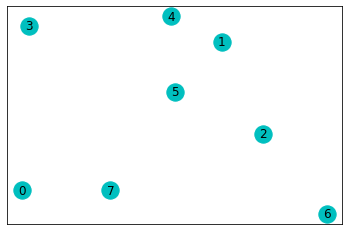

In [1]:
# 各倉庫を頂点とする Graph
import numpy as np

np.random.seed(100)
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# 頂点数を８とする
n = 8

# 各地点の座標を読み込む
vertices = pd.read_csv('data/Chapter4/vertices.csv').values
print('倉庫の座標')
print(vertices)

# Graph の作成
g = nx.DiGraph()

# n個の頂点を Graph に追加
g.add_nodes_from(range(n))

# 頂点座標の情報を Graph に追加しやすい形に整形
pos = dict(enumerate(zip(vertices[:, 0], vertices[:, 1])))

# Graph を描画
nx.draw_networkx(g, pos=pos, node_color='c')
print('倉庫の位置関係')
plt.show()

６つの Step をで Graph表現を用いて、Route を可視化。

1. 倉庫(頂点)の数を決める。
2. 各倉庫の座標を決める。
3. Graph の作成を宣言
4. 倉庫(頂点)を、Graph に追加
5. 整形し、描画

In [2]:
# 距離を求める

# 頂点感の距離を Matrix で表す
graph = np.linalg.norm(
    vertices[:, None] - vertices[None, :],
    axis=-1,
)
# graph(5, 3) は、頂点５から頂点３への距離
# graph(0, 7) は、頂点０から頂点７への距離

# わかりやすさのため小数点以下は切り捨て
graph = graph.astype(int)
print('倉庫間距離の Matrix')
print(graph)

倉庫間距離の Matrix
[[  0  86  74  70  86  61  90  26]
 [ 86   0  40  57  18  25  79  71]
 [ 74  40   0  82  56  31  38  51]
 [ 70  57  82   0  42  51 118  74]
 [ 86  18  56  42   0  32  95  76]
 [ 61  25  31  51  32   0  68  46]
 [ 90  79  38 118  95  68   0  64]
 [ 26  71  51  74  76  46  64   0]]


描画した倉庫(頂点)をたどって、各頂点間の距離を算出。
１行目２列目は０番倉庫(頂点)と１番倉庫(頂点)との距離、というふうに見る。

これら、各頂点間の距離をたどっていけば総移動距離を算出できるので、すべての倉庫をたどっていく Pattern（考え得るすべての巡回Route） の総移動距離をすべて計算し、それぞれを比較することによって、総移動距離が最短になる Route を選択すれば、それが最短Route となる。

In [3]:
# すべての巡回Route の総移動距離を計算した結果
from itertools import permutations

# 始点（終点）を決める
src = 0

# 経路を全列挙（始点は除いて列挙しておく）
routes = np.array([*permutations(range(1, 8))]).T

# 経路数を出力
m = routes.shape[1]
print(f"経路数: {m}")

# 始点を最初と最後に追加
routes = np.pad(routes, pad_width=((1, 1), (0, 0)), constant_values=src)
print(f"経路の列挙")
print(routes)

# 各径路について、総移動距離を一括で求める
dist = graph[routes[:-1], routes[1:]].sum(axis=0)
print('各径路の総移動距離')
print(dist)

経路数: 5040
経路の列挙
[[0 0 0 ... 0 0 0]
 [1 1 1 ... 7 7 7]
 [2 2 2 ... 6 6 6]
 ...
 [6 7 5 ... 3 1 2]
 [7 6 7 ... 1 2 1]
 [0 0 0 ... 0 0 0]]
各径路の総移動距離
[440 482 485 ... 471 403 440]


以上によって、すべての巡回Route の総移動距離が計算できたので、その中から最小のものを選択することによって、最短の移動距離と、その巡回Route が導出できる。

In [4]:
# 最短の総移動距離
print(f"最短距離: {dist.min()}")

最短距離: 314


In [5]:
# 経路を移動距離の短い順に Sort
i = np.argsort(dist)
routes = routes[:, i]
dist = dist[i]
print("経路の短い順に並び替える")
print(dist)

path = routes[:, 0]
print(f"最短経路: {path}")
print(f"最短距離: {dist[0]}")

経路の短い順に並び替える
[314 314 336 ... 618 620 620]
最短経路: [0 3 4 1 5 2 6 7 0]
最短距離: 314


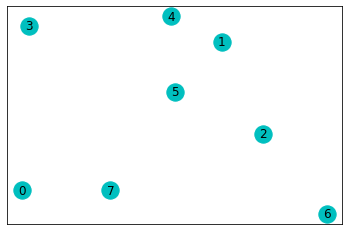

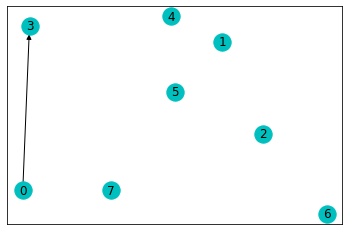

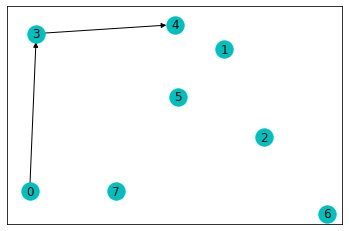

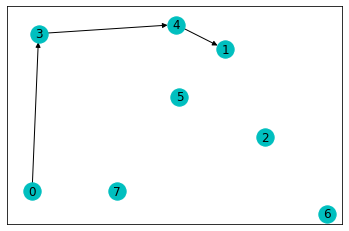

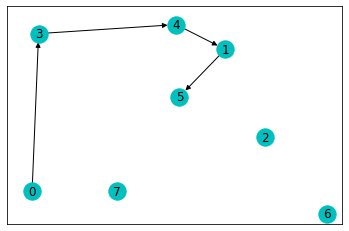

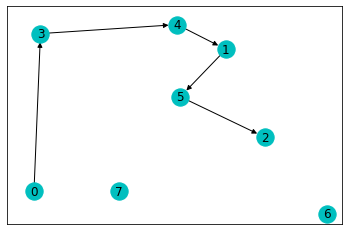

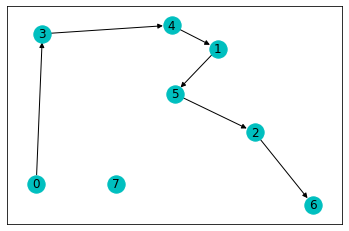

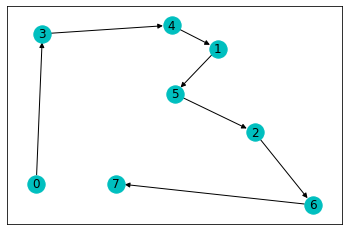

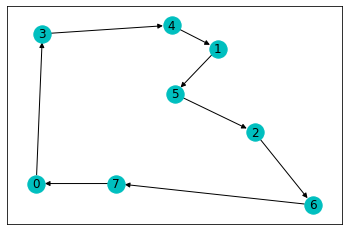

In [6]:
# 最短の巡回Route を表示する
for i in range(n):
    nx.draw_networkx(g, pos=pos, node_color='c')
    plt.show()
    g.add_edge(path[i], path[i + 1])
nx.draw_networkx(g, pos=pos, node_color='c')
plt.show()

for i in range(n):
    g.remove_edge(path[i], path[i + 1])

**全検索** は、倉庫の数が少ないうちは少ない計算時間で最短Route を導出できるが、要素の数が増えていくと、それに伴って計算時間が膨大になる。
そこで、効率的に最短Route を導出する方法を検討する必要がでてくる。

## Algorithm による問題の解き方を理解しよう

In [7]:
# for 文で和を求める

# n を100とする
n = 100
s = sum(i for i in range(1, n + 1))
print(f"和: {s}")

和: 5050


In [8]:
# 和の公式により求める
n = 10
s = (1 + n) * n // 2
print(f"和: {s}")

和: 55


In [9]:
# n が大きい場合
n = 10_000
s = (1 + n) * n // 2
print(f"和: {s}")

和: 50005000


Algorithm を工夫することで計算量を大きく圧縮することが可能になる。

## 動的計画法の Source Code を理解しよう

comparison_and_full_search library を作成

### Graph class:
巡回すべき倉庫の情報を与えることで、それぞれの倉庫間の移動距離を計算し、最短Route を計算するもの。

- Graph::Edge class:
  頂点である倉庫と倉庫の間(辺)の情報を持つ。
  - weight という変数に倉庫間の移動距離を格納する。

- __init__()
  引数 n として Graph の頂点の数（倉庫の数）を Instance変数として持つ。
- add_edge():
  頂点u, v間に辺を追加する
- generate_edge():
  全頂点間に Random な長さの辺を貼る。
-  calculate_dist():
  経路を渡すと距離を計算して返す。

### TSPBruteForce class（Graph を継承）
全探索によって最短Route を求める。

### TSPDP class(Graph class を継承）
動的計画法によって最短Route を求める。

DP
頂点数: 11
全検索
頂点数: 11


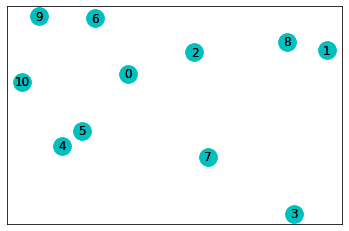

In [10]:
# CSV から Graph を生成
from comparison_df_and_full_search import TSPDP, Graph
from comparison_df_and_full_search import TSPBruteForce

print('DP')

g1 = TSPDP.from_csv('data/Chapter4/4_6_nodes.csv')
print('全検索')
g2 = TSPBruteForce.from_csv('data/Chapter4/4_6_nodes.csv')

In [11]:
%%time
# DP により距離と path を求める
d, path = g1(src=0)
print(f"距離: {d}")
print(f"経路: {path}")

計算回数: 10633
距離: 331
経路: [0, 6, 9, 10, 4, 5, 7, 3, 1, 8, 2, 0]
CPU times: total: 125 ms
Wall time: 126 ms


In [12]:
%%time
# 全探索により距離と path を求める
d, path = g2(src=0)
print(f"距離: {d}")
print(f"経路: {path}")

計算回数: 3628800
距離: 331
経路: [0, 6, 9, 10, 4, 5, 7, 3, 1, 8, 2, 0]
CPU times: total: 25.8 s
Wall time: 26 s


計算時間についても、動的計画法は全探索の 100分の１未満の時間で最短距離を求めることができることがわかる。

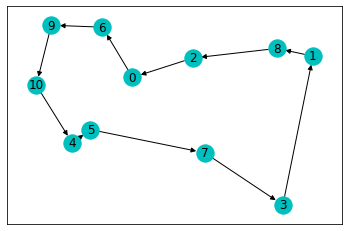

In [13]:
# path を可視化する
g2.show_path(path)

## 近似解を求めるという Approach を学ぼう
「全探索」は、厳密に最適解を求めることができる一方で、計算速度に関しては高速といえないために必要。

### Heuristic
厳密な意味では最適解とはいえない可能性があるが、「近似解」を経験的に求める、という考え方。

### 最近傍法
最短Route を求める問題に特化した方法。
- 「今いる頂点から最も近い頂点へ遷移する」ことを積み重ねることで、徐々に短い Route を見つけていく。
- 「貪欲法（Greedy）」という考え方が基礎になっている。
  後先のことは考えず（全体の最短Route に関しては一旦考えず）その場その場で最適な解を選択していく（局所的な最短Routeをたどっていく）というもので、最短Route を求める問題以外にも用いられる。

#### 最近傍法の Algorithm
1. 最初は始点にいる
2. 今いる頂点から、まだ訪れていない頂点までの距離をすべて求め、その中で最小となる頂点へ移動する。移動した頂点を訪問済みとし、今いる頂点とする。
3. 今いる頂点が終点であれば探索を終了し、そうでなければ 2. に戻って繰り返す

## 最近傍によって近似解を求めよう

最近傍法
頂点数: 18
DP
頂点数: 18


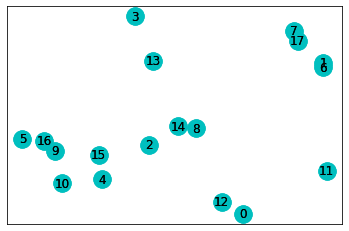

In [14]:
# Graph class を定義し、倉庫（頂点）の座標を CSV file によって与える
from t_s_p_nearest_neighbour import TSPNearestNeighbour

print('最近傍法')
g = TSPNearestNeighbour.from_csv('data/Chapter4/4_8_nodes.csv')
print('DP')
g2 = TSPDP.from_csv('data/Chapter4/4_8_nodes.csv')

計算回数: 306
距離: 375
経路: [0, 12, 11, 8, 14, 2, 15, 4, 10, 9, 16, 5, 13, 3, 7, 17, 1, 6, 0]


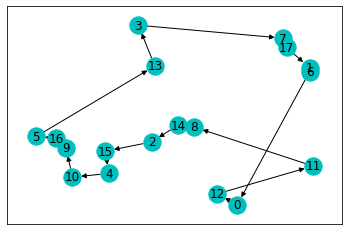

CPU times: total: 250 ms
Wall time: 245 ms


In [15]:
%%time
# 作成した Graph class に対して、最近傍法でその距離を求め、その計算時間を確認
d, path = g(src=0)
print(f"距離: {d}")
print(f"経路: {path}")
g.show_path(path)

- 総移動距離は、常に今居る場所から最も近い頂点へ移動していったときの移動距離の合計を表す。
- 計算回数は各Step ごとにどの頂点が最も近いかを計算するため、Ｎの二乗となる。

計算回数: 2782671
距離: 334
経路: [0, 12, 4, 10, 5, 16, 9, 15, 2, 14, 8, 13, 3, 7, 17, 1, 6, 11, 0]


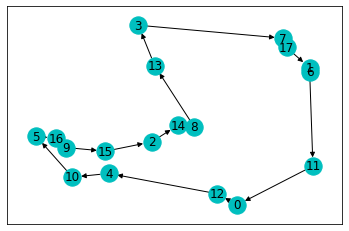

CPU times: total: 35.6 s
Wall time: 35.7 s


In [16]:
%%time
# 比較のため、動的計画法(DP)によって、同様のことを行なう
d2, path = g2(src=0)
print(f"距離: {d2}")
print(f"経路: {path}")
g.show_path(path)

- 最近傍法の計算時間は動的計画法（DP）遥かに上回るほど短時間。
- 近似解とはいえ、動的計画法（DP）で求めたものに近い Route を導き出すことができている。

※近似解である以上、厳密な解ではないことは常に意識が必要。

In [17]:
# 動的計画法（DP）による厳密解と最近傍による近似解を比較して相対誤差を計算する
print(f"相対誤差: {(d - d2) / d2}")

相対誤差: 0.12275449101796407


今回の計算では、およそ20%という誤差であることがわかた。

最近傍法の計算量は O(N^2) となるため、10,000頂点くらいであれば、十分高速に近似解を求めることができることがわかっている。

倉庫の位置関係


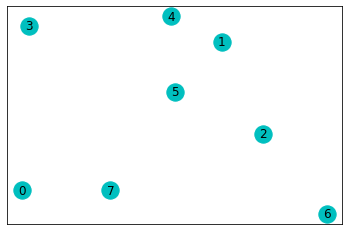

In [18]:
# 近似経路を可視化
import numpy as np

np.random.seed(100)
import networkx as nx
import matplotlib.pyplot as plt

n = 8
vertices = np.random.randint(1, 100, (n, 2))
g = nx.DiGraph()
g.add_nodes_from(range(n))
pos = dict(enumerate(zip(vertices[:, 0], vertices[:, 1])))
print('倉庫の位置関係')
nx.draw_networkx(g, pos=pos, node_color='c')
plt.show()

In [19]:
# 倉庫間距離を表示
from comparison_df_and_full_search import Graph

dist = vertices[:, None] - vertices[None, :]
dist = np.sqrt((dist ** 2).sum(axis=-1)).astype(int)
print('倉庫間距離の Matrix')
print(dist)

graph: Graph = TSPNearestNeighbour(n)
for i in range(n):
    for j in range(n):
        graph.add_edge(i, j, weight=dist[i, j])

倉庫間距離の Matrix
[[  0  86  74  70  86  61  90  26]
 [ 86   0  40  57  18  25  79  71]
 [ 74  40   0  82  56  31  38  51]
 [ 70  57  82   0  42  51 118  74]
 [ 86  18  56  42   0  32  95  76]
 [ 61  25  31  51  32   0  68  46]
 [ 90  79  38 118  95  68   0  64]
 [ 26  71  51  74  76  46  64   0]]


計算回数: 56


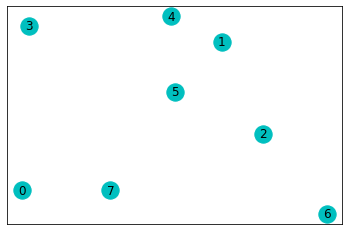

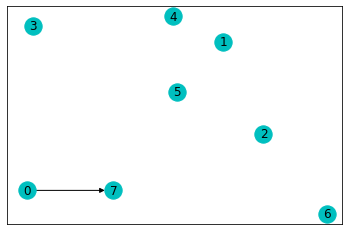

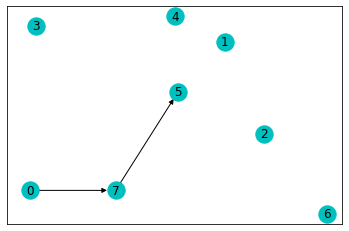

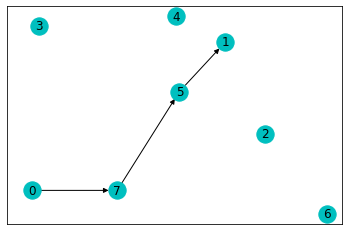

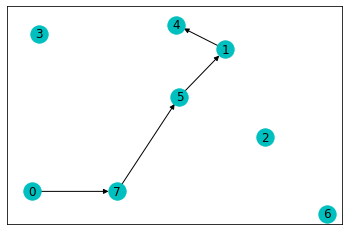

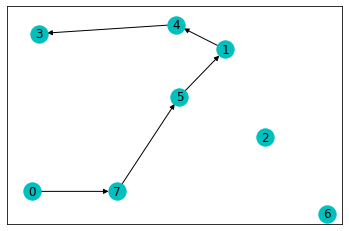

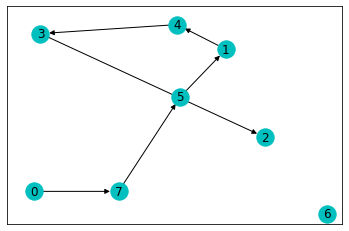

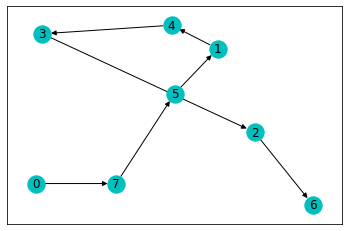

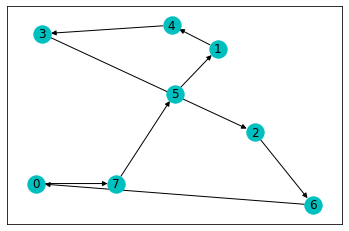

In [21]:
# 最近傍法により近似解を求めて経路を可視化する
d, path = graph(src=0)
n = len(path) - 1
for i in range(n):
    nx.draw_networkx(g, pos=pos, node_color='c')
    plt.show()
    g.add_edge(path[i], path[i+1])
nx.draw_networkx(g, pos=pos, node_color='c')
plt.show()

for i in range(n):
    g.remove_edge(path[i], path[i + 1])

#### その他の Heuristic 的に近似解を求める Algorithm
- insertion法
- 2-opt法
- 焼きなまし法
- LKH（※現状最も優れている Solver の１つ）

## 遺伝Algorithm を用いて近似解を求める方法を学ぼう

### 遺伝Algorithm（Genetic Algorithm: GA）
- 問題に特化せず、ある程度汎用的に最適化問題に摘要できる手法があれば、多くの問題を同じ方法で解くことが可能。そうした汎用性のある手法として有力なものの１つ。
- 生物が進化する方法を真似することによて、少しずつ解を改良していき、最適解に近いものを導きだすという考え方によって考案されたもの。
- 厳密解によって近い解が導出できるということは保証されていない一方、多くの最適化問題に対して、厳密解に近い近似解が計算できることが知られている。

#### 遺伝Algorithm（GA） の基本的な流れ
1. 初期世代の個体群を生成
2. 次世代の個体群を生成していく
  a. 交叉
  b. 突然変異
  c. 選択（淘汰）
3. 次世代の個体群を現世代として扱い、2. に戻って繰り返す

#### 遺伝的Algorithm で重要なこと
次世代の個体群をどのように生成するか。

- 交叉: 現世代（現世）の個体群の中から任意の Pair を選び、Pair の持つ遺伝子情報を一部入れ替えて次世代（子）を生成する。
- 突然変異: 生成された子をそのまま次世代に引き継ぐのではなく、生物の突然変異と同じように遺伝子情報を一部 Random に変化させること。
- 選択: 一部優秀で適応度が高い親をそのまま次世代の子として扱う。

上記、３種類の計算方法を組み合わせて生成するが、それぞれはあくまで考え方であり、具体的にどのような方法でそれらを実現するかについては、問題ごとに考える必要がある。